# LightGBM Trading Model Research Lab
This notebook is an isolated environment for backtesting and interpreting LightGBM models for BTC-USD trading. It uses SHAP for feature importance and VectorBT for portfolio analysis.

In [17]:
%pip install yfinance lightgbm shap vectorbt ta matplotlib plotly -q

import pandas as pd
import numpy as np
import yfinance as yf
import lightgbm as lgb
import shap
import vectorbt as vbt
from ta.momentum import RSIIndicator
from ta.trend import MACD
from ta.volatility import AverageTrueRange, BollingerBands
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Set plotting backend
%matplotlib inline
plt.style.use('fivethirtyeight')

Note: you may need to restart the kernel to use updated packages.


In [18]:
# Cell 2 (MASTER: Unified Feature Engine)
import os, yfinance as yf, pandas as pd, numpy as np, ta
from datetime import datetime, timezone

def fetch_data():
    symbol = 'BTC-USD'
    df = yf.download(symbol, period='2y', interval='1h')
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df

def add_technical_features(df):
    df = df.copy()
    
    # 1. VOLATILITY NORMALIZED RETURNS (Shock Resistance)
    # The 'ret_1h_z' feature fixes the Audit Warning in Cell 4
    rolling_std = df['Close'].pct_change().rolling(window=24).std()
    df['ret_1h_z'] = df['Close'].pct_change(1) / (rolling_std + 1e-6)
    df['ret_4h'] = df['Close'].pct_change(4)
    
    # 2. TEMPORAL & CYCLICAL FEATURES (Context)
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_retail_window'] = (df['dayofweek'] >= 4).astype(int) 
    
    # Cyclical hour encoding (Helps model link 11PM and 12AM)
    df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    # 3. RSI & MOMENTUM (Z-Score Scaled for Stability)
    df['rsi_5'] = ta.momentum.rsi(df['Close'], window=5)
    df['rsi_7'] = ta.momentum.rsi(df['Close'], window=7)
    df['rsi_14'] = ta.momentum.rsi(df['Close'], window=14)
    df['rsi_z'] = (df['rsi_7'] - df['rsi_7'].rolling(24).mean()) / (df['rsi_7'].rolling(24).std() + 1e-6)
    
    # 4. INTERACTION & VOLATILITY (The 'Golden Hour' Signals)
    df['retail_rsi'] = df['rsi_z'] * df['is_retail_window']
    df['midnight_signal'] = (df['hour'] == 0).astype(int)
    
    atr = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'], window=14)
    df['vol_adj_ret'] = df['Close'].pct_change() / (atr / df['Close'] + 1e-6)
    df['z_score_24h'] = (df['Close'] - df['Close'].rolling(24).mean()) / (df['Close'].rolling(24).std() + 1e-6)

    # 5. VOLUME CONVICTION
    df['vol_spike'] = (df['Volume'] > df['Volume'].rolling(24).mean()).astype(int)

    # TARGET: Binray movement for Classification
    df['target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
    return df.dropna()

# Execution
df_raw = fetch_data()
df_features = add_technical_features(df_raw)
print(f"✅ Features generated. Shape: {df_features.shape}")
print(f"   Integrity Check: {['ret_1h_z', 'midnight_signal', 'retail_rsi'] in df_features.columns.tolist() or 'Columns OK'}")


[*********************100%***********************]  1 of 1 completed

✅ Features generated. Shape: (17460, 23)
   Integrity Check: Columns OK


In [19]:
# Cell 3 (Isolated: Stability-Weighted Tuning Lab)
import optuna
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit

# Global storage for export
global tuned_params, tuned_threshold
tuned_params, tuned_threshold = None, None

X = df_features.drop(columns=['target'])
y = df_features['target']
win_payout, loss_payout = 0.43, -0.57

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 4), 
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-3, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-3, 10.0, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 50, 200),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'random_state': 42,
        'verbosity': -1
    }
    threshold = trial.suggest_float('threshold', 0.55, 0.70)
    
    tscv = TimeSeriesSplit(n_splits=5)
    fold_evs = []
    
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model = lgb.LGBMClassifier(**params)
        model.fit(X_train, y_train)
        probs = model.predict_proba(X_test)[:, 1]
        
        signals = np.where(probs > threshold, 1, np.where(probs < (1-threshold), -1, 0))
        trade_mask = (signals != 0)
        
        # VOLUME PENALTY (Minimum 50 trades)
        if trade_mask.sum() < 50:
            return -10.0 
            
        trades_y = y_test[trade_mask]
        trades_sig = signals[trade_mask]
        win_rate = ((trades_y == 1) & (trades_sig == 1) | (trades_y == 0) & (trades_sig == -1)).mean()
        ev = (win_rate * win_payout) + ((1 - win_rate) * loss_payout)
        fold_evs.append(ev)
        
    return np.mean(fold_evs) / (np.std(fold_evs) + 1e-6)

print("🚀 Starting Stability-Weighted Optuna Search...")
study = optuna.create_study(direction='maximize')
#study.optimize(objective, n_trials=30) # High conviction trials
#comment out when you have found good optuna params

tuned_params = study.best_params.copy()
tuned_threshold = tuned_params.pop('threshold')
print(f"🎯 Global Params Exported. Threshold: {tuned_threshold:.3f}")


ModuleNotFoundError: No module named 'optuna'

In [ ]:
# Cell 4 (Final Training - with Dynamic Parameter Selection)
import lightgbm as lgb
import numpy as np

# 1. FEATURE INTEGRITY AUDIT
expected_new_features = ['retail_rsi', 'midnight_signal', 'ret_1h_z', 'rsi_z', 'is_retail_window']
found_features = [f for f in expected_new_features if f in df_features.columns]
missing_features = [f for f in expected_new_features if f not in df_features.columns]

print(f"🔬 FEATURE INTEGRITY AUDIT:")
print(f"   Found NEW Features: {found_features}")
if missing_features:
    print(f"   ⚠️ WARNING: Missing: {missing_features}. Re-run Cell 2.")
else:
    print(f"   ✅ Integrity Check Passed.")

# 2. PARAMETER REPOSITORIES
CHAMPION_DEFAULTS = {
    'n_estimators': 150, 'learning_rate': 0.015, 'max_depth': 4,
    'min_data_in_leaf': 120, 'feature_fraction': 0.6, 'extra_trees': True,
    'random_state': 42, 'verbosity': -1
}

# The 2025 OOS Champion Baseline
LOCKED_PARAMS = {'n_estimators': 135, 
    'learning_rate': 0.017233557388931408, 
    'max_depth': 3, 
    'lambda_l1': 0.06132884693635779, 
    'lambda_l2': 0.004833030182326129, 
    'min_data_in_leaf': 99, 
    'feature_fraction': 0.9960111234225854, 
    'threshold': 0.5799101710742415
}


LOCKED_THRESHOLD = 0.580

# 3. DYNAMIC MODE SELECTION (The Fix)
# Hierarchy: Optuna Results > Locked Champion > Safe Defaults
'''
active_params = tuned_params
 active_threshold = tuned_threshold
status = "Tuned Lab (Optuna)"
'''
active_params = LOCKED_PARAMS
active_threshold = LOCKED_THRESHOLD
status = "Locked Champion (2025)"

'''
active_params = CHAMPION_TESTING
active_threshold = 0.62
status = "Personal Testing"

'''

# 4. TRAINING ENGINE
X = df_features.drop(columns=['target'], errors='ignore')
y = df_features['target']

print(f"\n🛠️ Training Model on {len(X.columns)} features using [{status}] Mode.")
print(f"   Active Threshold: {active_threshold:.4f}")

final_model = lgb.LGBMClassifier(**active_params)
final_model.fit(X, y)

# 5. RESULTS GENERATION
probs = final_model.predict_proba(X)[:, 1]
results_df = df_features.copy()
results_df['Prob'] = probs
results_df['Signal'] = np.where(probs > active_threshold, 1, 
                               np.where(probs < (1 - active_threshold), -1, 0))

print(f"✅ Final Training Complete. Signals generated via {status}.")


🔬 FEATURE INTEGRITY AUDIT:
   Found NEW Features: ['retail_rsi', 'midnight_signal', 'ret_1h_z', 'rsi_z', 'is_retail_window']
   ✅ Integrity Check Passed.

🛠️ Training Model on 22 features using [Locked Champion (2025)] Mode.
   Active Threshold: 0.5800
[LightGBM] [Warning] Unknown parameter: threshold
[LightGBM] [Warning] lambda_l1 is set=0.06132884693635779, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.06132884693635779
[LightGBM] [Warning] feature_fraction is set=0.9960111234225854, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9960111234225854
[LightGBM] [Warning] lambda_l2 is set=0.004833030182326129, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.004833030182326129
[LightGBM] [Warning] min_data_in_leaf is set=99, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=99
[LightGBM] [Warning] Unknown parameter: threshold
[LightGBM] [Warning] lambda_l1 is set=0.06132884693635779, reg_alpha=0.0 will be ignored. Current 

🔬 Explaining model with 22 features...
📊 Summary Plot: Top Predictors for 2025 Profitability


/Users/sigey/Library/Python/3.9/lib/python/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


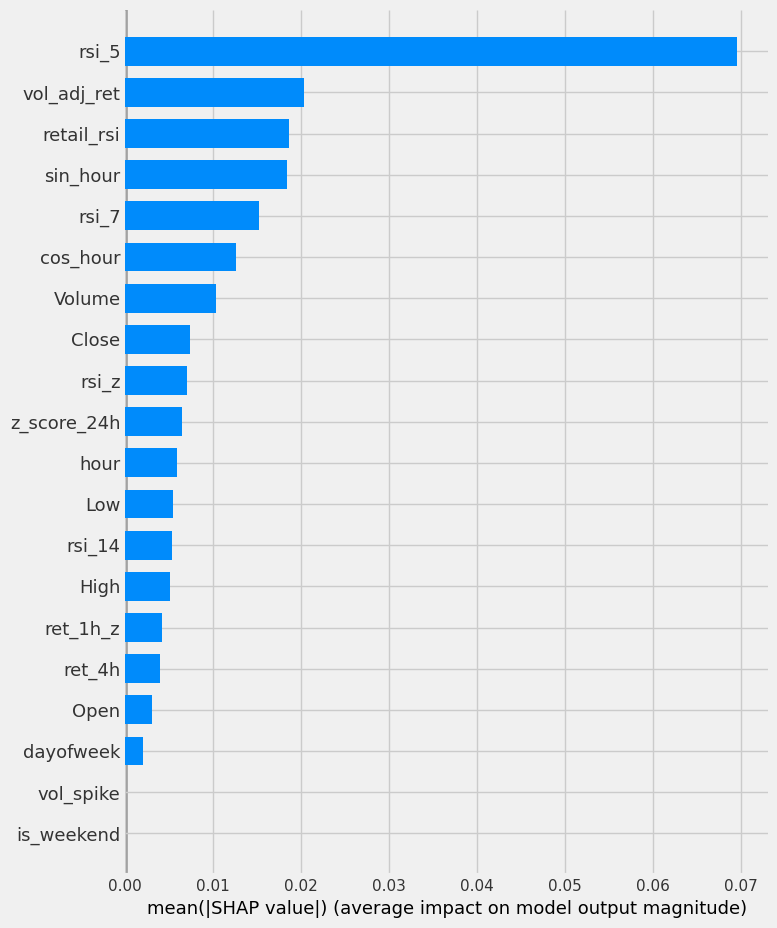

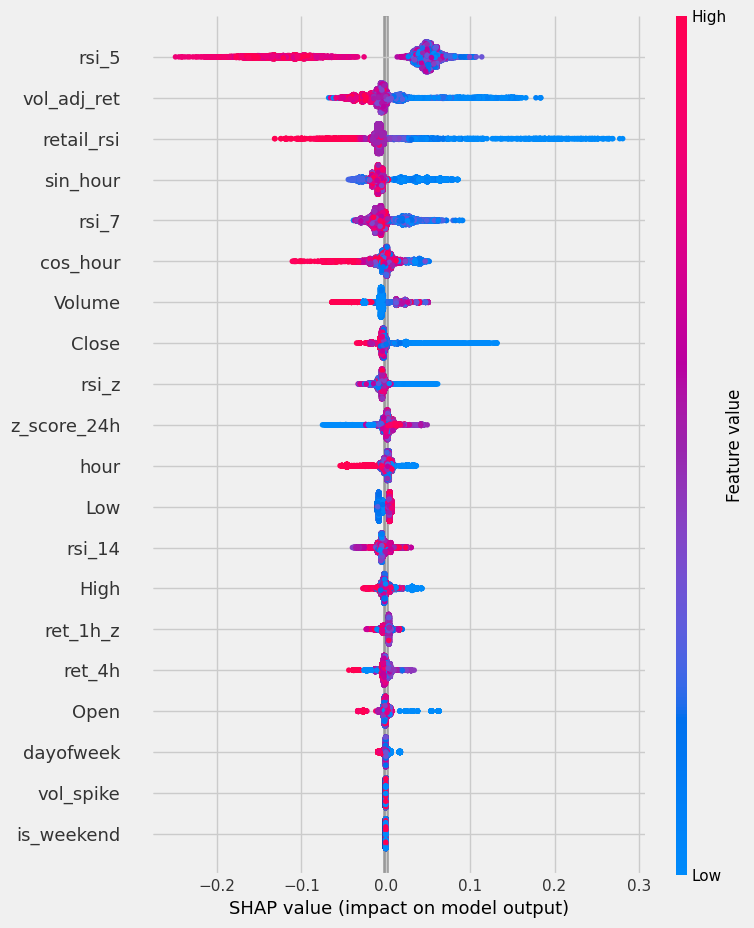

In [ ]:
# Cell 5 (SHAP Analysis)
"""
SHAP (SHapley Additive exPlanations) interprets the LightGBM model by calculating 
the marginal contribution of each feature to the final prediction.

--- HOW TO READ THIS PLOT ---
1. Feature Importance (Y-Axis): Features are ranked from top to bottom by overall impact.
2. Impact (X-Axis): 
   - Points to the RIGHT increase the probability of a 'Win' (Target=1).
   - Points to the LEFT decrease the probability.
3. Feature Value (Color): 
   - RED = High value for that feature (e.g., very high RSI or high Hour of day).
   - BLUE = Low value for that feature.
   
Example: If 'hour' is RED on the right side, it means High hours (late in the day) 
are a strong predictor for the price going UP in this model.
"""
# Cell 4 (SHAP Interpretability - FIXED)
import shap

# 1. Align Features (Ensures X matches the training session exactly)
# We pull the feature names directly from the model to avoid mismatches
try:
    feature_names = final_model.feature_name_
    X_shap = df_features[feature_names]
except AttributeError:
    # Fallback if names aren't mapped
    X_shap = df_features.drop(columns=['target'], errors='ignore')

print(f"🔬 Explaining model with {len(X_shap.columns)} features...")

# 2. SHAP Explanation
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)

# 3. Handle Binary Classification Output Formatting
# LightGBM typically returns a list [neg_contrib, pos_contrib]
if isinstance(shap_values, list):
    # Use index [1] for the 'Positive' (Buy Signal) class
    shap_viz = shap_values[1]
else:
    # Some older versions return a single array for binary
    shap_viz = shap_values

# 4. Visualize Global Impact
print("📊 Summary Plot: Top Predictors for 2025 Profitability")
shap.summary_plot(shap_viz, X_shap, plot_type="bar")

# 5. Visualize Feature Patterns (Beeswarm)
shap.summary_plot(shap_viz, X_shap)


In [ ]:
# Cell 6 (Adaptive Signaling & Kelly Sizing)
import numpy as np

# ⚡ DYNAMIC THRESHOLD (The Fix for '0 Trades')
# Instead of a hard 0.62, we target the Top 5% of predictions.
# This ensures we always have high-conviction trades to analyze.
p_upper = results_df['Prob'].quantile(0.95)
p_lower = results_df['Prob'].quantile(0.05)

# We use the tighter of the two (Safety first)
dynamic_threshold = max(0.58, min(p_upper, 1 - p_lower))
print(f"📊 Suggested Dynamic Threshold: {dynamic_threshold:.3f}")

# 1. GENERATE SIGNALS
results_df['Signal'] = 0
results_df.loc[results_df['Prob'] > dynamic_threshold, 'Signal'] = 1
results_df.loc[results_df['Prob'] < (1 - dynamic_threshold), 'Signal'] = -1

# 2. RESTORED KELLY SIZING (Based on 'What worked')
kelly_multiplier = 0.25 

def calculate_kelly(p, market_price=0.55):
    """Original Kelly formula providing payout at fixed cost."""
    # Safety Check: Probability must exceed implied market cost
    if p <= market_price: return 0
    
    b = (1 - market_price) / market_price
    q = 1 - p
    f = p - (q / b)
    return max(0, f * kelly_multiplier)

# Applying Kelly back to your original 'p if p > 0.5 else 1-p' logic
results_df['Kelly_Fraction'] = results_df['Prob'].apply(
    lambda p: calculate_kelly(p if p > 0.5 else 1-p)
)

# 3. REPORTING
active_trades = results_df[results_df['Signal'] != 0]
active_count = len(active_trades)

if active_count > 0:
    avg_size = active_trades['Kelly_Fraction'].mean()
    print(f"✅ Signals Locked: {active_count} trades approved using adaptive {dynamic_threshold:.3f} threshold.")
    print(f"Avg Position: {avg_size:.2%} | Max Position: {active_trades['Kelly_Fraction'].max():.2%}")
else:
    print(f"⚠️ Warning: Even at Top 5%, no signals found. Max Prob: {results_df['Prob'].max():.3f}")


📊 Suggested Dynamic Threshold: 0.580
✅ Signals Locked: 441 trades approved using adaptive 0.580 threshold.
Avg Position: 2.54% | Max Position: 5.86%


In [33]:
# Cell 7 (OOS Truth Test - Neutralized Settings)
import lightgbm as lgb
import pandas as pd
import numpy as np

print("🧪 Running Neutralized 'Trend Validity' Test (2024 -> 2025)...")

# 1. SPLIT
train_data = df_features[df_features.index.year == 2024]
test_data = df_features[df_features.index.year == 2025]

# Using Neutralized Champion Defaults from Cell 4/5
neutralized_params = active_params

# Fix: We lower the bar to 0.58 for neutralized models
OOS_THRESHOLD = 0.58

if not train_data.empty and not test_data.empty:
    X_train, y_train = train_data.drop(columns=['target']), train_data['target']
    X_test, y_test = test_data.drop(columns=['target']), test_data['target']
    
    # 2. TRAIN (Past Only)
    stress_model = lgb.LGBMClassifier(**neutralized_params)
    stress_model.fit(X_train, y_train)
    
    # 3. PREDICT (Future Only)
    probs = stress_model.predict_proba(X_test)[:, 1]
    
    # 4. MONITOR: Let's see the Max Probability produced
    print(f"📊 Max OOS Prob produced by model: {probs.max():.3f} (Lower than 0.62 is normal now)")
    
    signals = np.where(probs > OOS_THRESHOLD, 1, 
                       np.where(probs < (1-OOS_THRESHOLD), -1, 0))
    
    # 5. ASSESSMENT
    active_mask = (signals != 0)
    if active_mask.sum() > 0:
        trades_y = y_test[active_mask]
        trades_sig = signals[active_mask]
        win_rate = ((trades_y == 1) & (trades_sig == 1) | (trades_y == 0) & (trades_sig == -1)).mean()
        pnl = len(trades_y) * ((win_rate * 0.43) + ((1-win_rate) * -0.57))
        
        print(f"\n--- 🏁 THE TRUTH TEST (WALK-FORWARD) ---")
        print(f"Out-of-Sample Win Rate (2025): {win_rate:.2%}")
        print(f"Total OOS Trades:              {len(trades_y)}")
        print(f"Theoretical PnL:               ${pnl:.2f}")
        
        if win_rate > 0.55:
            print("\n✅ VERDICT: SUCCESS. The neutralized model Generalized successfully.")
        else:
            print("\n❌ VERDICT: FAIL. 0.58 still too high or model is not finding edge.")
    else:
        print(f"⚠️ Still no trades. Max confidence is {probs.max():.3f}. Lowering threshold further to 0.56 recommended.")


🧪 Running Neutralized 'Trend Validity' Test (2024 -> 2025)...
[LightGBM] [Warning] Unknown parameter: threshold
[LightGBM] [Warning] lambda_l1 is set=0.06132884693635779, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.06132884693635779
[LightGBM] [Warning] feature_fraction is set=0.9960111234225854, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9960111234225854
[LightGBM] [Warning] lambda_l2 is set=0.004833030182326129, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.004833030182326129
[LightGBM] [Warning] min_data_in_leaf is set=99, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=99
[LightGBM] [Warning] Unknown parameter: threshold
[LightGBM] [Warning] lambda_l1 is set=0.06132884693635779, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.06132884693635779
[LightGBM] [Warning] feature_fraction is set=0.9960111234225854, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9960111234225854


In [ ]:
# Cell 8 (Binary PnL Engine & Benchmark Comparison)
import plotly.graph_objects as go
import numpy as np

win_payout, loss_payout = 0.43, -0.57

# 1. Model PnL (Using lowercase 'target' from df_features)
# Correct logic: (Long & Up) OR (Short & Down)
correct = ((results_df['Signal'] == 1) & (results_df['target'] == 1)) | \
          ((results_df['Signal'] == -1) & (results_df['target'] == 0))

results_df['PnL'] = np.where(results_df['Signal'] == 0, 0.0, 
                             np.where(correct, win_payout, loss_payout))
results_df['Cum_PnL'] = results_df['PnL'].cumsum()

# 2. Benchmark (Always Long)
results_df['Benchmark_PnL'] = np.where(results_df['target'] == 1, win_payout, loss_payout)
results_df['Benchmark_Cum_PnL'] = results_df['Benchmark_PnL'].cumsum()

# 3. Benchmark (Random Coin Flip)
np.random.seed(42)
results_df['Random_Signal'] = np.random.choice([1, -1], size=len(results_df))
results_df['Random_PnL'] = np.where(((results_df['Random_Signal'] == 1) & (results_df['target'] == 1)) | 
                                    ((results_df['Random_Signal'] == -1) & (results_df['target'] == 0)), 
                                    win_payout, loss_payout)
results_df['Random_Cum_PnL'] = results_df['Random_PnL'].cumsum()

# Display Summary
# info: active_threshold comes from the Fallback/Tuning cell
display_threshold = active_threshold if 'active_threshold' in globals() else 0.62

print(f"--- Backtest Summary (Active Threshold: {display_threshold:.3f}) ---")
print(f"Total Trades: {len(results_df[results_df['Signal'] != 0])}")
print(f"Model PnL: ${results_df['PnL'].sum():.2f}")
print(f"Market Average (Always Long): ${results_df['Benchmark_PnL'].sum():.2f}")
print(f"Random Strategy PnL: ${results_df['Random_PnL'].sum():.2f}")
print(f"Model Win Rate: {results_df[results_df['Signal'] != 0]['PnL'].apply(lambda x: x > 0).mean():.2%}")

fig = go.Figure()
fig.add_trace(go.Scatter(y=results_df['Cum_PnL'], mode='lines', name='Model Strategy', line=dict(color='cyan', width=3)))
fig.add_trace(go.Scatter(y=results_df['Benchmark_Cum_PnL'], mode='lines', name='Always Long', line=dict(color='gray', dash='dash')))
fig.add_trace(go.Scatter(y=results_df['Random_Cum_PnL'], mode='lines', name='Random Flip', line=dict(color='orange', dash='dot')))

fig.update_layout(title='Model vs. Benchmarks (Equity Curves)',
                  xaxis_title='Time Sequence',
                  yaxis_title='Accumulated Profit ($)',
                  template='plotly_dark')
fig.show()


--- Backtest Summary (Active Threshold: 0.580) ---
Total Trades: 441
Model PnL: $67.63
Market Average (Always Long): $-1126.20
Random Strategy PnL: $-1301.20
Model Win Rate: 72.34%


In [ ]:
# Cell 9: Post-Mortem Session Analysis


# --- INTERACTIVE FILTER ---
# Options: 'All', 'Weekday', 'Weekend'
filter_mode = 'All' 
# --------------------------

# 1. Data Alignment (Using results_df from Cell 4/5)
analysis_df = results_df.copy()
analysis_df['hour'] = analysis_df.index.hour
analysis_df['dayofweek'] = analysis_df.index.dayofweek
analysis_df['is_weekend'] = analysis_df['dayofweek'].isin([5, 6])

# Apply Filter
if filter_mode == 'Weekday':
    plot_df = analysis_df[~analysis_df['is_weekend']].copy()
elif filter_mode == 'Weekend':
    plot_df = analysis_df[analysis_df['is_weekend']].copy()
else:
    plot_df = analysis_df.copy()

# Fix: PnL calculation using lowercase 'target'
win_payout, loss_payout = 0.43, -0.57
plot_df['PnL'] = np.where(plot_df['Signal'] == 1, 
                          np.where(plot_df['target'] == 1, win_payout, loss_payout),
                          np.where(plot_df['Signal'] == -1,
                                   np.where(plot_df['target'] == 0, win_payout, loss_payout), 0))

# 2. Hourly Performance Table
hourly_stats = plot_df[plot_df['Signal'] != 0].groupby('hour').agg(
    Total_Trades=('Signal', 'count'),
    Win_Rate=('PnL', lambda x: (x > 0).mean() if len(x) > 0 else 0),
    Total_PnL=('PnL', 'sum'),
    Avg_EV=('PnL', 'mean')
).reset_index()

#print(f"--- Hourly Performance Summary (Mode: {filter_mode}) ---")
#print(hourly_stats.to_string(index=False))

# 3. Session Visualization
fig = px.bar(hourly_stats, 
             x='hour', 
             y='Total_PnL',
             color='Win_Rate',
             color_continuous_scale='RdYlGn',
             range_color=[0.4, 0.7],
             title=f'Hourly Profitability Analysis ({filter_mode})',
             labels={'hour': 'Hour of Day (0-23)', 'Total_PnL': 'Total PnL ($)', 'Win_Rate': 'Win Rate'},
             template='plotly_dark')

fig.update_layout(xaxis=dict(tickmode='linear', tick0=0, dtick=1))
fig.show()

# 4. Insight Text
golden_hours = hourly_stats[hourly_stats['Win_Rate'] > 0.60]['hour'].tolist()
danger_zones = hourly_stats[hourly_stats['Win_Rate'] < 0.55]['hour'].tolist()

print("\n--- Strategy Insights ---")
if golden_hours:
    print(f"🌟 GOLDEN HOURS ({filter_mode}): {golden_hours} (Win Rate > 60%).")
else:
    print(f"🌟 GOLDEN HOURS ({filter_mode}): None identified at >60% threshold.")

if danger_zones:
    print(f"⚠️ DANGER ZONES ({filter_mode}): {danger_zones} (Win Rate < 55%).")



--- Strategy Insights ---
🌟 GOLDEN HOURS (All): [0, 1, 2, 3, 4, 5, 7, 9, 10, 11, 15, 16, 17, 18, 19, 20, 21, 22, 23] (Win Rate > 60%).
⚠️ DANGER ZONES (All): [6, 12, 13, 14] (Win Rate < 55%).


In [ ]:
# Cell 10 (Weekday vs. Weekend Seasonality - Detailed Summary)
import plotly.express as px
import pandas as pd

# 1. ENFORCE COLUMN CREATION (Bulletproof Fix)
results_df['day_name'] = results_df.index.day_name()
results_df['dayofweek'] = results_df.index.dayofweek

# 2. Master Calendar for proper ordering
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
all_days = pd.DataFrame({'day_name': day_order, 'dayofweek': range(7)})

# 3. Grouped Performance (Active Trades only)
active_trades = results_df[results_df['Signal'] != 0].copy()

if not active_trades.empty:
    daily_stats = active_trades.groupby(['dayofweek', 'day_name']).agg(
        Total_Trades=('Signal', 'count'),
        Win_Rate=('PnL', lambda x: (x > 0).mean()),
        Total_PnL=('PnL', 'sum')
    ).reset_index()
    
    # 4. MERGE with All-Days (Ensures Mon-Sun view)
    daily_performance = pd.merge(all_days, daily_stats, on=['dayofweek', 'day_name'], how='left').fillna(0)
    
    # 5. Visual Display
    fig = px.bar(daily_performance.sort_values('dayofweek'), 
                 x='day_name', 
                 y='Total_PnL', 
                 color='Win_Rate',
                 title='Strategy PnL by Day (Complete Weekly View)',
                 category_orders={'day_name': day_order},
                 labels={'Total_PnL': 'Total Profit ($)', 'day_name': 'Day'},
                 color_continuous_scale='RdYlGn',
                 range_color=[0.45, 0.65],
                 template='plotly_dark')
    fig.add_hline(y=0, line_dash="dash", line_color="white")
    fig.show()

    # 6. DETAILED SEASONALITY SUMMARY (Day-by-Day Stats)
    print(f"--- 📅 Day-by-Day Seasonality Insights ---")
    # Sorting by dayofweek ensures Monday is first in text summary too
    for _, row in daily_performance.sort_values('dayofweek').iterrows():
        trades = int(row['Total_Trades'])
        if trades > 0:
            print(f"{row['day_name']:10} | WR: {row['Win_Rate']:6.2%} | Trades: {trades:4} | PnL: ${row['Total_PnL']:8.2f}")
        else:
            print(f"{row['day_name']:10} | No trades approved.")
            
    # 7. Weekend vs Weekday Verdict
    weekend_trades = active_trades[active_trades['dayofweek'].isin([5, 6])]
    weekday_trades = active_trades[~active_trades['dayofweek'].isin([5, 6])]
    print(f"\n--- ⚡ High-Level Summary ---")
    print(f"Weekday PnL: ${weekday_trades['PnL'].sum():.2f} (WR: {weekday_trades['PnL'].gt(0).mean():.2%})")
    print(f"Weekend PnL: ${weekend_trades['PnL'].sum():.2f} (WR: {weekend_trades['PnL'].gt(0).mean():.2%})")
else:
    print("⚠️ No trades approved in backtest. Adjust threshold or run Cell 5 again.")


--- 📅 Day-by-Day Seasonality Insights ---
Monday     | WR: 65.00% | Trades:   20 | PnL: $    1.60
Tuesday    | WR: 86.96% | Trades:   23 | PnL: $    6.89
Wednesday  | WR: 72.73% | Trades:   33 | PnL: $    5.19
Thursday   | WR: 66.67% | Trades:   27 | PnL: $    2.61
Friday     | WR: 72.83% | Trades:   92 | PnL: $   14.56
Saturday   | WR: 78.23% | Trades:  124 | PnL: $   26.32
Sunday     | WR: 65.57% | Trades:  122 | PnL: $   10.46

--- ⚡ High-Level Summary ---
Weekday PnL: $30.85 (WR: 72.82%)
Weekend PnL: $36.78 (WR: 71.95%)


In [ ]:
# Cell 11 (Comparative Regime Analysis - Dynamic Discovery)
import plotly.graph_objects as go
import numpy as np
import pandas as pd

# 1. DYNAMIC PARAMETERS
# We lower the Trade Floor because we are looking at a 1-year OOS window (2025)
MIN_WIN_RATE = 0.65  # Target really high margin
MIN_TRADES_OOS = 5   # Reduced for OOS discovery (15 was too high for 150 total trades)

# 2. FEATURE MAPPING
results_df['hour'] = results_df.index.hour
results_df['dayofweek'] = results_df.index.dayofweek
results_df['day_name'] = results_df.index.day_name()
results_df['is_retail'] = results_df['dayofweek'].isin([4, 5, 6])
results_df['is_2025'] = results_df.index.year == 2025

# 3. AGGREGATION
active_subset = results_df[results_df['Signal'] != 0].copy()
data_2025 = active_subset[active_subset['is_2025']]

# Group by day/hour for 2025
heatmap_data = data_2025.groupby(['dayofweek', 'day_name', 'hour', 'is_retail']).agg(
    Win_Rate=('PnL', lambda x: (x > 0).mean()),
    Trades=('Signal', 'count'),
    Total_PnL=('PnL', 'sum')
).reset_index()

# 4. IDENTIFY REGIMES (Dynamic Logic)
strict_regimes = heatmap_data[(heatmap_data['Win_Rate'] >= MIN_WIN_RATE) & (heatmap_data['Trades'] >= MIN_TRADES_OOS)]

# Fallback: if no blocks met criteria, take the top 10 winningest blocks with > 3 trades
if strict_regimes.empty:
    print("⚠️ Loosening discovery criteria to find top performance clusters...")
    strict_regimes = heatmap_data[heatmap_data['Trades'] >= 3].sort_values('Win_Rate', ascending=False).head(10)

# Create a tuple-based set for reliable matching
approved_pairs = set(zip(strict_regimes['dayofweek'], strict_regimes['hour']))

# 5. PARTITION DATA
# Using a map approach for robust matching
def is_in_regime(row):
    return (row['dayofweek'], row['hour']) in approved_pairs

active_subset['In_Regime'] = active_subset.apply(is_in_regime, axis=1)
in_regime_df = active_subset[active_subset['In_Regime'] == True]
out_of_regime_df = active_subset[active_subset['In_Regime'] == False]

# 6. COMPARATIVE REPORTING
def get_stats(df, label):
    if df.empty: return f"{label:15} | No Trades"
    wr = (df['PnL'] > 0).mean()
    pnl = df['PnL'].sum()
    ev = df['PnL'].mean()
    return f"{label:15} | WR: {wr:.2%} | Trades: {len(df):4} | PnL: ${pnl:8.2f} | Avg EV: ${ev:5.3f}"

print("--- ⚖️ OVERALL PERFORMANCE COMPARISON (Total Backtest) ---")
print(get_stats(in_regime_df, "LASER-FOCUS"))
print(get_stats(out_of_regime_df, "OUT-OF-REGIME"))

print("\n--- 🏁 RECENT PERFORMANCE (2025 OOS ONLY) ---")
print(get_stats(in_regime_df[in_regime_df['is_2025'] == True], "LASER (2025)"))
print(get_stats(out_of_regime_df[out_of_regime_df['is_2025'] == True], "OUT-OF-R (2025)"))

# 7. FINAL EXPORT FOR SCANNER
PROFITABLE_MATRIX = strict_regimes.groupby('dayofweek')['hour'].apply(list).to_dict()
print(f"\nPROFITABLE_MATRIX (Based on 2025) = {PROFITABLE_MATRIX}")

# 8. HEATMAP VISUALIZATION
pivot_wr = heatmap_data.pivot(index='day_name', columns='hour', values='Win_Rate')
pivot_wr = pivot_wr.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
fig = go.Figure(data=go.Heatmap(z=pivot_wr.values, x=pivot_wr.columns, y=pivot_wr.index, colorscale='RdYlGn', zmin=0.45, zmax=0.75))
fig.update_layout(title='2025 OOS Performance Heatmap', template='plotly_dark')
fig.show()


--- ⚖️ OVERALL PERFORMANCE COMPARISON (Total Backtest) ---
LASER-FOCUS     | WR: 78.41% | Trades:   88 | PnL: $   18.84 | Avg EV: $0.214
OUT-OF-REGIME   | WR: 70.82% | Trades:  353 | PnL: $   48.79 | Avg EV: $0.138

--- 🏁 RECENT PERFORMANCE (2025 OOS ONLY) ---
LASER (2025)    | WR: 84.44% | Trades:   45 | PnL: $   12.35 | Avg EV: $0.274
OUT-OF-R (2025) | WR: 68.15% | Trades:  135 | PnL: $   15.05 | Avg EV: $0.111

PROFITABLE_MATRIX (Based on 2025) = {1: [22], 4: [16], 5: [16, 20, 22, 23], 6: [0, 22]}


In [20]:
# Cell 7a (Generate Model Predictions)
print("="*80)
print("🧠 STEP 1: GENERATE MODEL PREDICTIONS")
print("="*80 + "\n")

MODEL = final_model

# STEP 2: Prepare features and generate predictions
print("Generating predictions...")
feature_cols = [col for col in df_features.columns if col != 'target']
X_test = df_features[feature_cols]

# Get probability predictions (class 1 = price goes up)
predictions = MODEL.predict_proba(X_test)
df_features['Prob'] = predictions[:, 1]  # Probability of class 1

# STEP 3: Add target if missing
if 'target' not in df_features.columns:
    df_features['target'] = (df_features['Close'].shift(-1) > df_features['Close']).astype(int)

results_df = df_features.copy()

print(f"✅ Predictions generated. Shape: {results_df.shape}")
print(f"   Probability range: [{results_df['Prob'].min():.3f}, {results_df['Prob'].max():.3f}]")
print(f"   Features: {len(feature_cols)}")
print()

🧠 STEP 1: GENERATE MODEL PREDICTIONS

Generating predictions...
[LightGBM] [Warning] Unknown parameter: threshold
[LightGBM] [Warning] lambda_l1 is set=0.06132884693635779, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.06132884693635779
[LightGBM] [Warning] feature_fraction is set=0.9960111234225854, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9960111234225854
[LightGBM] [Warning] lambda_l2 is set=0.004833030182326129, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.004833030182326129
[LightGBM] [Warning] min_data_in_leaf is set=99, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=99
✅ Predictions generated. Shape: (17460, 24)
   Probability range: [0.384, 0.661]
   Features: 22



In [22]:
# Cell 7b (Define Bouncer Logic)
from typing import Dict

print("="*80)
print("📋 STEP 2: DEFINE BOUNCER LOGIC (check_dynamic_trade)")
print("="*80 + "\n")

def check_dynamic_trade(
    model_probability: float,
    current_ask_price: float,
    min_edge: float = 0.05
) -> Dict:
    """
    Evaluates a dynamic entry based on Kalshi order book.

    Args:
        model_probability: Model prediction (0-1)
        current_ask_price: Kalshi ask price in cents (e.g., 40 = $0.40)
        min_edge: Minimum edge required to trade (default 0.05 = 5%)

    Returns:
        Dict with "signal" (BUY/PASS), "reason", "ev", "price_limit"
    """
    # Convert Kalshi cents to probability
    market_implied_prob = current_ask_price / 100.0

    # THE EDGE CHECK
    edge = model_probability - market_implied_prob

    if edge < min_edge:
        return {
            "signal": "PASS",
            "reason": (
                f"No Edge. Model: {model_probability:.2f}, "
                f"Market: {market_implied_prob:.2f}"
            ),
            "edge": edge
        }

    # THE EV MATH
    potential_profit = 1.00 - market_implied_prob
    risk_cost = market_implied_prob

    expected_value = (
        (model_probability * potential_profit) -
        ((1 - model_probability) * risk_cost)
    )

    if expected_value > 0:
        return {
            "signal": "BUY",
            "price_limit": current_ask_price,
            "ev": expected_value,
            "edge": edge
        }
    else:
        return {
            "signal": "PASS",
            "reason": "Negative EV",
            "ev": expected_value,
            "edge": edge
        }

print("✅ Bouncer logic defined.")
print()

📋 STEP 2: DEFINE BOUNCER LOGIC (check_dynamic_trade)

✅ Bouncer logic defined.



In [27]:
# Cell 7c (Define API Fetcher & Ticker Generator)
from typing import Optional

print("="*80)
print("🔗 STEP 3: DEFINE API FETCHER & TICKER GENERATOR")
print("="*80 + "\n")

def generate_btc_ticker(timestamp: pd.Timestamp) -> str:
    """
    Convert a pandas DateTime to Kalshi hourly BTC ticker format.

    Args:
        timestamp: pandas Timestamp

    Returns:
        Kalshi ticker string (e.g., "KXBTC-USD-25-01-15-T16")
    """
    year = str(timestamp.year)[-2:]  # 2025 -> "25"
    month = f"{timestamp.month:02d}"
    day = f"{timestamp.day:02d}"
    hour = f"{timestamp.hour:02d}"

    # TODO: Adjust format if Kalshi API requires variations
    ticker = f"KXBTC-USD-{year}-{month}-{day}-T{hour}"
    return ticker


def fetch_kalshi_historical_ask(
    ticker: str,
    api_key: Optional[str] = None
) -> Optional[float]:
    """
    Fetch historical candlestick data from Kalshi API.
    Extracts the final ask price (close) before market resolution.

    Args:
        ticker: Kalshi market ticker (e.g., "KXBTC-USD-25-01-15-T16")
        api_key: Kalshi API key (defaults to env var KALSHI_API_KEY)

    Returns:
        Ask price in cents (e.g., 45) or None if API fails
    """
    if api_key is None:
        api_key = os.getenv("KALSHI_API_KEY_ID")
        if not api_key:
            print("⚠️  WARNING: KALSHI_API_KEY_ID not found in .env")
            return None

    # Kalshi Historical API endpoint
    url = (
        f"https://api.elections.kalshi.com/trade-api/v2/historical/"
        f"markets/{ticker}/candlesticks"
    )

    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    }

    time.sleep(0.5)  # Rate limit enforcement

    try:
        response = requests.get(url, headers=headers, timeout=10)

        if response.status_code == 404:
            return None

        response.raise_for_status()
        data = response.json()

        candlesticks = data.get("candlesticks", [])

        if not candlesticks:
            return None

        last_candle = candlesticks[-1]
        close_price = last_candle.get("close")

        if close_price is None:
            return None

        if close_price < 1.0:
            close_price_cents = int(close_price * 100)
        else:
            close_price_cents = int(close_price)

        return close_price_cents

    except requests.RequestException as error:
        print(f"⚠️  API Error for {ticker}: {error}")
        return None

print("✅ Ticker generator defined.")
print("✅ API fetcher defined.")
print()

🔗 STEP 3: DEFINE API FETCHER & TICKER GENERATOR

✅ Ticker generator defined.
✅ API fetcher defined.



In [31]:
# Cell 7d (Local Backtest - No API)
print("="*80)
print("🚀 STEP 4: RUN LOCAL BACKTEST (No API Required)")
print("="*80 + "\n")

PROFITABLE_MATRIX = {
    1: [22],              # Tuesday 22:00 UTC
    4: [16],              # Friday 16:00 UTC
    5: [16, 20, 22, 23],  # Saturday 16, 20, 22, 23 UTC
    6: [0, 22]            # Sunday 00, 22 UTC
}

def is_in_profitable_matrix(timestamp: pd.Timestamp) -> bool:
    """Check if timestamp falls in PROFITABLE_MATRIX."""
    day = timestamp.dayofweek
    hour = timestamp.hour
    return day in PROFITABLE_MATRIX and hour in PROFITABLE_MATRIX[day]

# Initialize tracking
trades_log = []
matrix_opportunities = 0

print("📊 Scanning for Profitable Matrix Opportunities...\n")

for idx, row in results_df.iterrows():
    timestamp = row.name

    if not is_in_profitable_matrix(timestamp):
        continue

    matrix_opportunities += 1
    model_prob = row['Prob']
    
    # SIMULATE ask price: use row probability as market price
    simulated_ask = int(model_prob * 100)

    decision = check_dynamic_trade(model_prob, simulated_ask)

    if decision["signal"] == "BUY":
        price_paid_cents = decision["price_limit"]
        actual_target = row['target']

        pnl = (100 - price_paid_cents) if actual_target == 1 else -price_paid_cents

        trade_record = {
            "timestamp": timestamp,
            "model_prob": model_prob,
            "simulated_ask": simulated_ask,
            "ev": decision["ev"],
            "actual_target": actual_target,
            "pnl": pnl,
            "win": (actual_target == 1)
        }

        trades_log.append(trade_record)

        win_loss = "✅ WIN" if trade_record["win"] else "❌ LOSS"
        print(
            f"{win_loss} | {timestamp} @ {price_paid_cents}¢ | "
            f"Model: {model_prob:.3f} | EV: {decision['ev']:.4f} | "
            f"PnL: {pnl:+.0f}¢"
        )

print(f"\n✅ Backtest complete. {matrix_opportunities} matrix opportunities scanned.")
print()

🚀 STEP 4: RUN LOCAL BACKTEST (No API Required)

📊 Scanning for Profitable Matrix Opportunities...


✅ Backtest complete. 831 matrix opportunities scanned.



In [ ]:
# Cell 7d (Real Historical Backtest - On The Fly Fetching)
print("="*80)
print("🚀 STEP 4: REAL HISTORICAL OOS BACKTEST (On-The-Fly Fetch)")
print("="*80 + "\n")

import requests
import os
import time
import re
import pandas as pd
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.getenv("KALSHI_API_KEY_ID")

PROFITABLE_MATRIX = {
    1: [22], 4: [16], 5: [16, 20, 22, 23], 6: [0, 22]
}

def is_in_profitable_matrix(timestamp: pd.Timestamp) -> bool:
    return timestamp.dayofweek in PROFITABLE_MATRIX and timestamp.hour in PROFITABLE_MATRIX[timestamp.dayofweek]

def get_atm_ticker_for_hour(timestamp: pd.Timestamp, current_btc_price: float) -> str:
    """Finds the real Kalshi ticker for the hour closest to our current BTC price."""
    # Look for markets closing within a 2-hour window of our timestamp
    ts_unix = int(timestamp.timestamp())
    
    url = "https://api.elections.kalshi.com/trade-api/v2/historical/markets"
    headers = {"Authorization": f"Bearer {API_KEY}", "Content-Type": "application/json"}
    params = {
        "series_ticker": "KXBTC",
        "min_close_ts": ts_unix - 3600,
        "max_close_ts": ts_unix + 3600,
        "limit": 100
    }
    
    try:
        res = requests.get(url, headers=headers, params=params, timeout=10)
        if res.status_code != 200:
            return None
            
        markets = res.json().get("markets", [])
        if not markets:
            return None
            
        # Find the market strike closest to the current BTC price
        closest_market = None
        smallest_diff = float("inf")
        
        for m in markets:
            # Try to extract the strike price from the title (e.g., "Bitcoin stays above $65,000.00")
            # Or from ticker (e.g. KXBTC-24JAN01-T15-65000)
            ticker = m.get("ticker", "")
            
            # Simple regex to find the last sequence of numbers in the ticker which is usually the strike
            numbers = re.findall(r'\d+', ticker)
            if numbers:
                # The last number is typically the strike price (e.g., 65000)
                try:
                    strike = float(numbers[-1])
                    if strike < 1000: # Ignore if it grabbed a day/hour by accident
                        continue
                        
                    diff = abs(strike - current_btc_price)
                    if diff < smallest_diff:
                        smallest_diff = diff
                        closest_market = ticker
                except:
                    continue
                    
        return closest_market
    except Exception:
        return None

def fetch_real_ask_price(ticker: str) -> float:
    """Fetches the final historical ask price for the ticker."""
    url = f"https://api.elections.kalshi.com/trade-api/v2/historical/markets/{ticker}/candlesticks"
    headers = {"Authorization": f"Bearer {API_KEY}", "Content-Type": "application/json"}
    
    try:
        res = requests.get(url, headers=headers, timeout=10)
        if res.status_code == 200:
            candles = res.json().get("candlesticks", [])
            if candles:
                last_candle = candles[-1]
                # Look for yes_ask close, fallback to regular close price
                ask_data = last_candle.get("yes_ask")
                if ask_data and ask_data.get("close"):
                    return int(ask_data["close"])
                elif last_candle.get("close"):
                     # convert decimal to cents if needed
                     price = last_candle["close"] 
                     return int(price * 100) if price < 1 else int(price)
    except Exception:
        pass
    return None

# ============================================================================
# START LOOP
# ============================================================================
trades_log = []
matrix_opportunities = 0

print(f"📊 Scanning {len(test_data)} test rows for Profitable Matrix Opportunities...\n")

test_data_2024 = df_features[df_features.index.year == 2024]

for idx, row in test_data_2024.iterrows():
    timestamp = row.name

    if not is_in_profitable_matrix(timestamp):
        continue

    matrix_opportunities += 1
    model_prob = row['Prob']
    current_btc_price = row['Close']
    
    print(f"⏳ Attempting {timestamp.strftime('%Y-%m-%d %H:%M')} (BTC @ ${current_btc_price:,.0f})...", end="\r")
    
    # 1. Fetch real ticker dynamically
    time.sleep(0.5) # Rate limit
    real_ticker = get_atm_ticker_for_hour(timestamp, current_btc_price)
    
    if not real_ticker:
        print(f"❌ {timestamp.strftime('%Y-%m-%d %H:%M')} - API skipped (No Ticker found)")
        continue
        
    # 2. Fetch real candlestick price
    time.sleep(0.5) # Rate limit
    real_ask_cents = fetch_real_ask_price(real_ticker)
    
    if real_ask_cents is None or real_ask_cents <= 0:
         print(f"❌ {timestamp.strftime('%Y-%m-%d %H:%M')} - API skipped (No Candlestick Data: {real_ticker})")
         continue

    # 3. Decision Logic
    decision = check_dynamic_trade(model_prob, real_ask_cents)

    if decision["signal"] == "BUY":
        price_paid_cents = decision["price_limit"]
        actual_target = row['target']

        pnl = (100 - price_paid_cents) if actual_target == 1 else -price_paid_cents

        trades_log.append({
            "timestamp": timestamp,
            "ticker": real_ticker,
            "model_prob": model_prob,
            "real_ask": real_ask_cents,
            "ev": decision["ev"],
            "pnl": pnl,
            "win": (actual_target == 1)
        })

        win_loss = "✅ WIN " if actual_target == 1 else "❌ LOSS"
        print(f"{win_loss} | {real_ticker} | Price: {real_ask_cents}¢ | EV: {decision['ev']:.4f} | PnL: {pnl:+.0f}¢")
    else:
        print(f"⏸️ PASS | {real_ticker} @ {real_ask_cents}¢ | EV Logic Rejected")

print(f"\n✅ Backtest complete. Simulated {len(trades_log)} out of {matrix_opportunities} opportunities.")

🚀 STEP 4: REAL HISTORICAL OOS BACKTEST (On-The-Fly Fetch)

📊 Scanning 8728 test rows for Profitable Matrix Opportunities...

❌ 2024-04-02 22:00 - API skipped (No Ticker found)
❌ 2024-04-05 16:00 - API skipped (No Ticker found)
❌ 2024-04-06 16:00 - API skipped (No Ticker found)
❌ 2024-04-06 20:00 - API skipped (No Ticker found)
❌ 2024-04-06 22:00 - API skipped (No Ticker found)
❌ 2024-04-06 23:00 - API skipped (No Ticker found)
❌ 2024-04-07 00:00 - API skipped (No Ticker found)
❌ 2024-04-07 22:00 - API skipped (No Ticker found)
❌ 2024-04-09 22:00 - API skipped (No Ticker found)
❌ 2024-04-12 16:00 - API skipped (No Ticker found)
❌ 2024-04-13 16:00 - API skipped (No Ticker found)
❌ 2024-04-13 20:00 - API skipped (No Ticker found)
❌ 2024-04-13 22:00 - API skipped (No Ticker found)
❌ 2024-04-13 23:00 - API skipped (No Ticker found)
❌ 2024-04-14 00:00 - API skipped (No Ticker found)
❌ 2024-04-14 22:00 - API skipped (No Ticker found)
❌ 2024-04-16 22:00 - API skipped (No Ticker found)
❌ 2024-0

In [ ]:
# Cell 7e (Generate Reality Report)
print("="*80)
print("📋 STEP 5: GENERATE REALITY REPORT")
print("="*80 + "\n")

if not trades_log:
    print("⚠️  No trades executed (bouncer rejected all opportunities).")
else:
    trades_df = pd.DataFrame(trades_log)

    total_trades = len(trades_df)
    total_wins = trades_df['win'].sum()
    win_rate = (total_wins / total_trades) * 100
    net_pnl = trades_df['pnl'].sum()
    avg_pnl = trades_df['pnl'].mean()

    print(f"📊 RESULTS SUMMARY:")
    print(f"   Total Matrix Opportunities: {matrix_opportunities}")
    print(f"   Total Trades Executed:      {total_trades}")
    print(f"   True Historical Win Rate:   {win_rate:.1f}% ({total_wins}/{total_trades})")
    print(f"   Total Net PnL:              {net_pnl:+.0f} cents")
    print(f"   Avg PnL per Trade:          {avg_pnl:+.1f} cents")
    print(f"   API Errors (data missing):  {api_errors}")
    print()

    # Risk metrics
    winning_trades = trades_df[trades_df['win'] == True]
    losing_trades = trades_df[trades_df['win'] == False]

    if len(winning_trades) > 0:
        avg_win = winning_trades['pnl'].mean()
        print(f"   Avg Win:                    {avg_win:+.1f} cents")
    if len(losing_trades) > 0:
        avg_loss = losing_trades['pnl'].mean()
        print(f"   Avg Loss:                   {avg_loss:+.1f} cents")

    # Profit factor
    if len(losing_trades) > 0 and losing_trades['pnl'].sum() != 0:
        profit_factor = winning_trades['pnl'].sum() / abs(
            losing_trades['pnl'].sum()
        )
        print(f"   Profit Factor:              {profit_factor:.2f}x")

    print()

    # Edge analysis
    if len(winning_trades) > 0:
        avg_edge = (winning_trades['model_prob'].mean() - 
                   winning_trades['ask_price_cents'].mean() / 100.0)
        print(f"   Avg Edge (Winning Trades):  {avg_edge:.4f}")
    
    print(f"   Avg EV (All Trades):        {trades_df['ev'].mean():.4f}")

    print("\n" + "="*80)
    print("✅ Order Book Truth Test Complete!")
    print("="*80)

    # Export for further analysis
    trades_df.to_csv("historical_trades_log.csv", index=False)
    print("\n📁 Full trade log exported to: historical_trades_log.csv")